# Movie recommendation engine: analysis walk-through

**Stakeholder:** a streaming product team. **Decision:** which 10 titles to show each user. **KPIs:** NDCG@10 and recall@10 on
each user's *future* ratings, plus catalogue coverage (a model that recommends the same 30 blockbusters to everyone is a
poor product even if its accuracy looks fine) and cold-start behaviour.
**Data:** MovieLens 1M (GroupLens): 1,000,209 ratings, 6,040 users, 3,706 movies. Downloaded on demand, never committed (licence).

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image
from recsys import config, data, experiment as ex, models as M
from recsys.explain import because_you_liked, shared_genres

S = ex.build()
ds = S.ds
r = ds.ratings
print(f"{ds.n_users:,} users, {ds.n_items:,} movies, {len(r):,} ratings, density {len(r) / (ds.n_users * ds.n_items):.1%}")
print(r.rating.value_counts(normalize=True).sort_index().round(3).to_dict())

6,040 users, 3,706 movies, 1,000,209 ratings, density 4.5%
{1: 0.056, 2: 0.108, 3: 0.261, 4: 0.349, 5: 0.226}


Ratings are dense for a recommender dataset (4.5% filled) and the catalogue has a long tail: a few blockbusters gather most
of the likes, which is exactly why a popularity list is a hard baseline to beat.

In [2]:
likes = np.asarray(S.pos_train.sum(0)).ravel()
share = np.sort(likes)[::-1].cumsum() / likes.sum()
print("share of all likes captured by the top 1% / 10% / 50% of movies:",
      [round(float(share[int(len(share) * q) - 1]), 3) for q in (0.01, 0.10, 0.50)])
lab = data.chronological_split(r)
print(lab.value_counts(normalize=True).round(3).to_dict())

share of all likes captured by the top 1% / 10% / 50% of movies: [0.139, 0.568, 0.963]


{'train': 0.7, 'test': 0.2, 'val': 0.1}


## Evaluation design (the part that decides whether the numbers mean anything)

* **Per-user chronological split**: each user's earliest 70% of ratings train the models, the next 10% tune them, the last 20%
  are the held-out future. A random split would let the model peek at a user's later taste.
* **"Liked" = rating of 4 or 5.** Test relevance is a liked movie in the future slice; already-rated movies are never recommended.
* **Tune on validation, refit on train+validation, grade once on test.** Metrics are bootstrapped over users.

In [3]:
res = json.loads((config.ARTIFACTS / "results.json").read_text())
tr = pd.DataFrame(res["tuning"]["trials"])
tr["params"] = tr.params.astype(str)
show = tr.sort_values("ndcg", ascending=False).groupby("model").head(3).sort_values(["model", "ndcg"], ascending=[True, False])
show[["model", "params", "ndcg", "recall", "coverage"]].round(4)

,model,params,ndcg,recall,coverage
21,als,"{'factors': 32, 'alpha': 3.0, 'reg': 1.0}",0.0866,0.0983,0.2294
19,als,"{'factors': 32, 'alpha': 3.0, 'reg': 0.01}",0.0864,0.0986,0.2304
20,als,"{'factors': 32, 'alpha': 3.0, 'reg': 0.3}",0.0864,0.0981,0.2288
23,content,"{'blocks': 'genres+era', 'w': [1, 0.5, 0]}",0.0140,0.0152,0.9085
25,content,"{'blocks': 'genres+era+title', 'w': [1, 0.5, 0...",0.0128,0.0150,0.5521
22,content,"{'blocks': 'genres', 'w': [1, 0, 0]}",0.0117,0.0129,0.8904
34,hybrid,"{'w_knn': 1.0, 'w_content': 0.0}",0.0944,0.1057,NaN
36,hybrid,"{'w_knn': 1.0, 'w_content': 0.25}",0.0944,0.1060,NaN
35,hybrid,"{'w_knn': 1.0, 'w_content': 0.1}",0.0943,0.1057,NaN
8,item_knn,"{'k': 100, 'shrink': 10.0}",0.0926,0.0969,0.2728


Validation findings: ALS liked *low* confidence (alpha 3; higher values over-trust each like and collapse quality from
0.085 to 0.072); more latent factors did not help beyond 32; the regulariser barely mattered; item-KNN's neighbourhood size
plateaued at 100. In the content model, adding era helped slightly while title words did not.

In [4]:
t = res["test"]["models"]
df = pd.DataFrame({k: {"NDCG@10": v["ndcg"], "95% CI": f"{v['ndcg_ci'][0]:.3f}-{v['ndcg_ci'][1]:.3f}",
                       "Recall@10": v["recall"], "Hit rate@10": v["hit"], "Coverage": v["coverage"],
                       "Novelty": v["novelty"]} for k, v in t.items()}).T
df

,NDCG@10,95% CI,Recall@10,Hit rate@10,Coverage,Novelty
random,0.005431,0.005-0.006,0.002791,0.048441,1.0,14.858287
popularity,0.092392,0.089-0.096,0.047535,0.380489,0.033189,7.971426
item_knn,0.125642,0.121-0.130,0.084009,0.515756,0.277118,8.936934
als,0.125464,0.121-0.130,0.087718,0.531009,0.245818,9.132716
content,0.016936,0.015-0.018,0.014179,0.112638,0.90286,14.718101
hybrid,0.131072,0.127-0.136,0.089895,0.532182,0.25742,9.031403


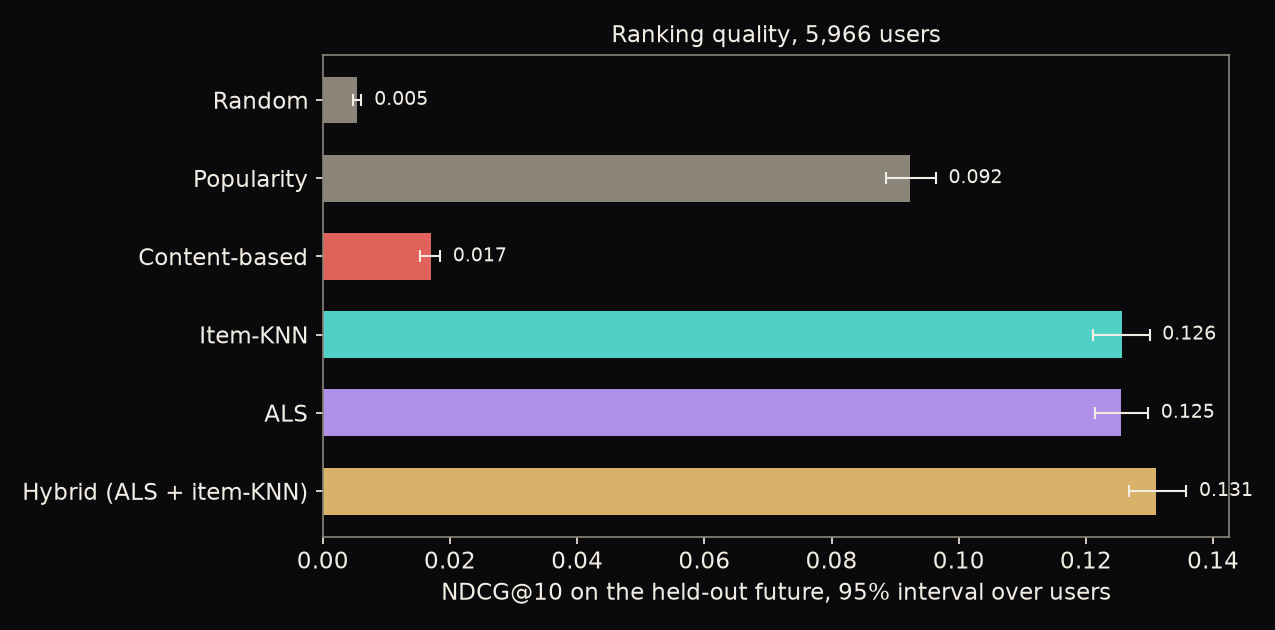

In [5]:
Image(str(config.FIGURES / "01_model_comparison.png"))

**Findings**
* Every personalised model clearly beats popularity (paired NDCG@10 gain 0.033 for ALS and item-KNN, 95% CI about 0.029-0.037).
* **ALS and item-KNN are statistically tied** (difference -0.0002, CI -0.003 to +0.003). ALS is not a silver bullet on this data.
* The **hybrid (ALS + item-KNN)** adds a small but real +0.0056 (CI 0.004-0.007): the two models make different mistakes.
* **Content-based alone is weak** (0.017, barely 3x random) because 18 genres cannot separate 3,700 movies. Its value is elsewhere: it is the
  only one of these models that can rank a movie nobody has rated (see below).

In [6]:
d = res["test"]["paired_ndcg_diffs"]
pd.DataFrame({k: {"mean diff": v["mean"], "CI low": v["ci"][0], "CI high": v["ci"][1]} for k, v in d.items()}).T.round(4)

,mean diff,CI low,CI high
hybrid_minus_popularity,0.0387,0.0344,0.0430
als_minus_popularity,0.0331,0.0285,0.0373
item_knn_minus_popularity,0.0332,0.0290,0.0373
hybrid_minus_als,0.0056,0.0039,0.0074
als_minus_item_knn,-0.0002,-0.0034,0.0032
hybrid_minus_item_knn,0.0054,0.0034,0.0079


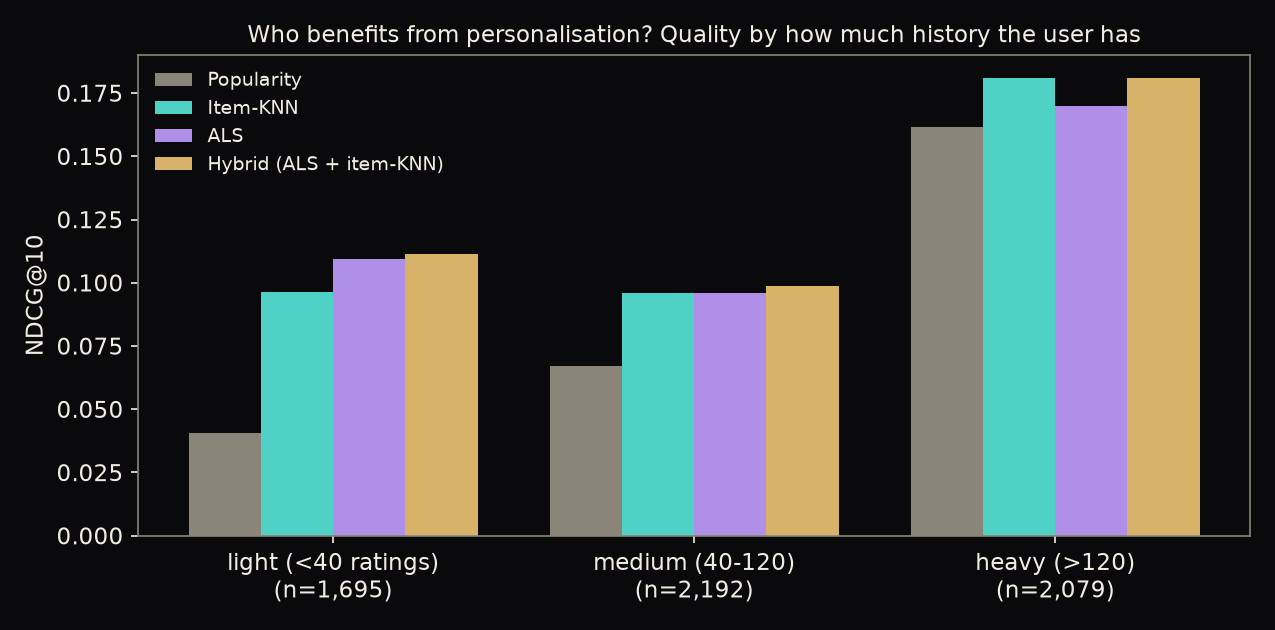

In [7]:
Image(str(config.FIGURES / "03_segments.png"))

Personalisation helps **light users most** in relative terms (NDCG 0.040 -> 0.11, almost 3x) because popularity is a poor guess
for someone with a few unusual tastes; for heavy users popularity is already strong (0.16) and personalisation adds ~12%.

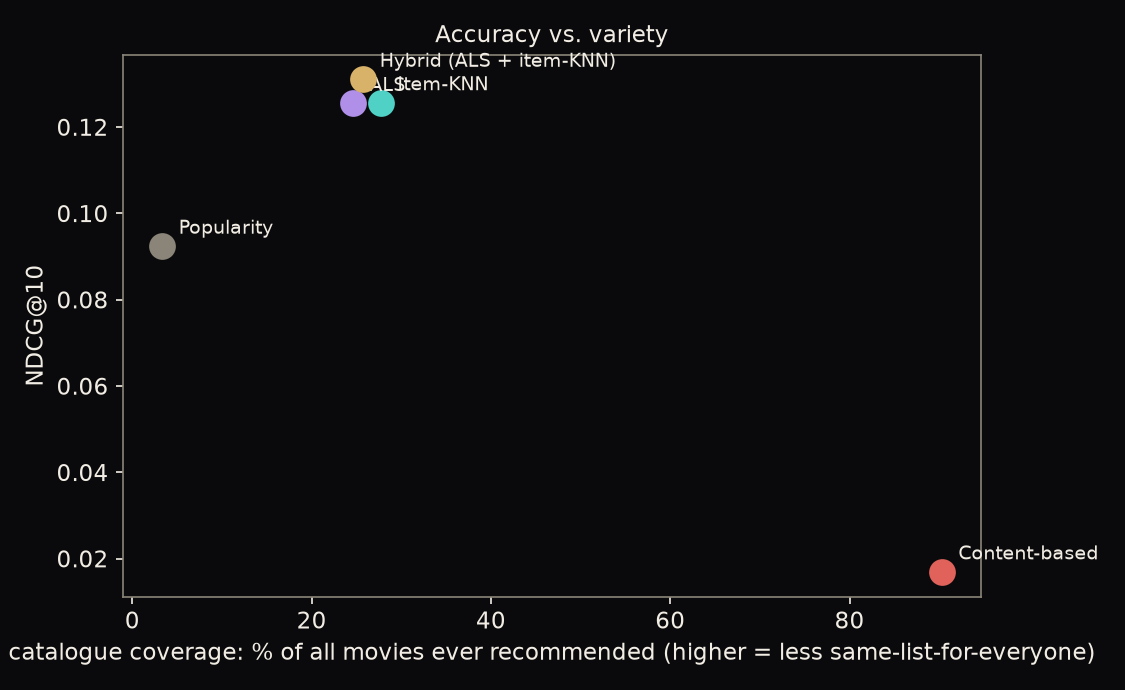

In [8]:
Image(str(config.FIGURES / "04_accuracy_vs_coverage.png"))

Popularity recommends just **3.3%** of the catalogue to everyone; the collaborative models reach ~25% and recommend more niche movies
(novelty 9.0 vs 8.0 bits), at higher accuracy, so here diversity does not cost accuracy.

## Cold start

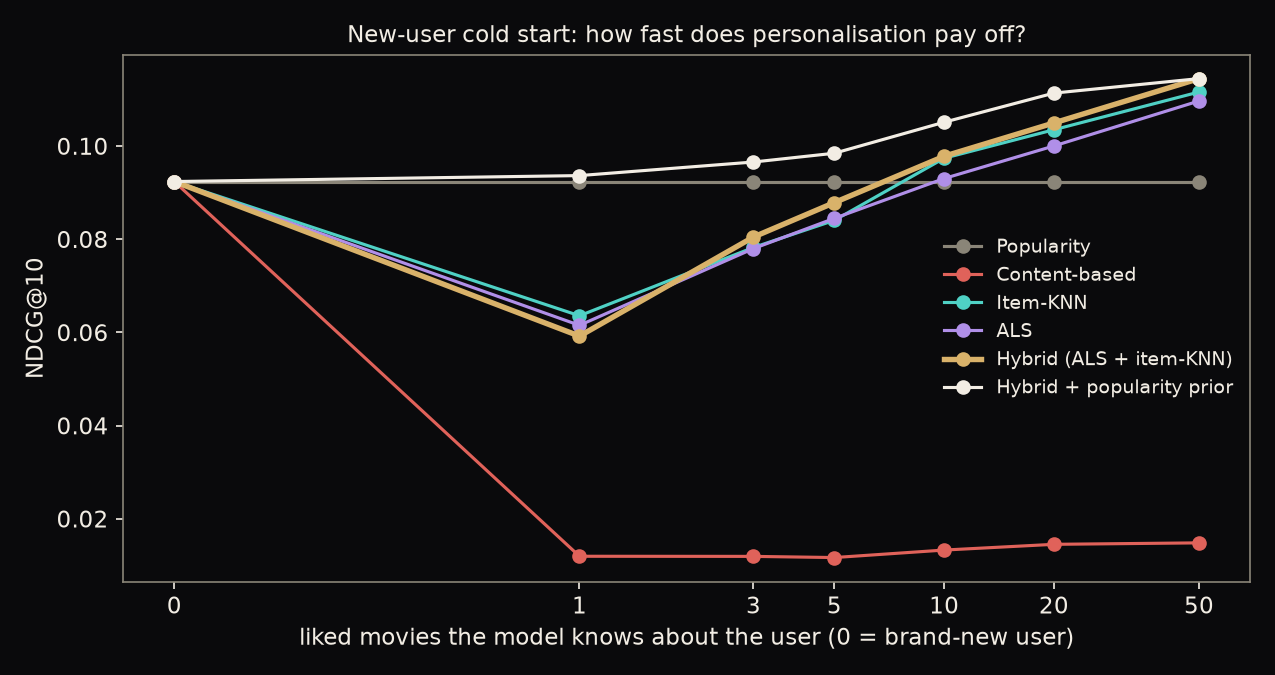

In [9]:
Image(str(config.FIGURES / "02_cold_start_users.png"))

In [10]:
cs = res["cold_start_users"]
pd.DataFrame({int(m): {k: v["ndcg"] for k, v in row.items()} for m, row in cs.items()}).T.round(4)

,popularity,item_knn,als,content,hybrid,hybrid_pop
0,0.0924,0.0924,0.0924,0.0924,0.0924,0.0924
1,0.0924,0.0636,0.0615,0.0120,0.0592,0.0937
3,0.0924,0.0782,0.0780,0.0119,0.0805,0.0966
5,0.0924,0.0841,0.0845,0.0117,0.0879,0.0985
10,0.0924,0.0974,0.0930,0.0133,0.0978,0.1051
20,0.0924,0.1035,0.1000,0.0145,0.1050,0.1114
50,0.0924,0.1116,0.1097,0.0148,0.1145,0.1145


**New user.** With only 1-5 liked movies the personalised models are *worse than popularity* (NDCG 0.059 at m=1 vs 0.092): a couple
of picks is a noisy signal. They overtake popularity at about 10 liked movies. A **popularity prior blended in with a weight tuned on
validation data per history length** (weights 4, 2, 1, 0.5, 0.5, 0 for m = 1, 3, 5, 10, 20, 50) is at least as good as the better of the two at every m.

In [11]:
ni = res["cold_start_items"]
print(f"{ni['n_cold_items']} movies hidden from training entirely; {ni['n_users']:,} users with a liked cold movie later")
pd.DataFrame(ni["variants"]).T[["ndcg", "recall", "hit"]].round(4)

370 movies hidden from training entirely; 3,850 users with a liked cold movie later


,ndcg,recall,hit
random,0.016658,0.026963,0.071688
genres,0.047751,0.079561,0.152208
genres+era,0.045299,0.076536,0.125455
genres+title,0.041331,0.072404,0.137403
genres+era+title,0.045651,0.081684,0.137922


**New item.** With no ratings, ALS and item-KNN have nothing to score. Ranking the hidden movies by content similarity to a user's
likes gets NDCG@10 ~0.048 against 0.017 for random (about 2.9x). Genres alone did as well as genres + era + title words: modest but
real, and it is the *only* signal available for a brand-new title.

## Explanations: exact, not a story

In [12]:
best = json.loads((config.ARTIFACTS / "hyperparams.json").read_text())
als = M.ALS.from_factors(np.load(config.ARTIFACTS / "item_factors.npy"), best["als"]["reg"], best["als"]["alpha"])
u = 359
liked = S.pos_trainval[u].indices
seen = S.seen_trainval[u].indices
h = S.pos_trainval[u]
from recsys import metrics
rec = metrics.top_k(als.score(h), S.seen_trainval[u], 5)[0]
for i in rec:
    why = because_you_liked(als, liked, int(i), k=3)
    print(f"{ds.movies.title.iloc[i]:45s} <- " + ", ".join(f"{ds.movies.title.iloc[j]} ({s:.0%})" for j, s in why))

Star Wars: Episode IV - A New Hope            <- Star Wars: Episode V - The Empire Strikes Back (19%), Raiders of the Lost Ark (18%), Star Wars: Episode VI - Return of the Jedi (17%)
Toy Story 2                                   <- Bug's Life, A (24%), Who Framed Roger Rabbit? (9%), Stuart Little (7%)
E.T. the Extra-Terrestrial                    <- Star Wars: Episode V - The Empire Strikes Back (15%), Star Wars: Episode VI - Return of the Jedi (10%), Raiders of the Lost Ark (8%)
Superman                                      <- Star Trek IV: The Voyage Home (9%), Star Trek III: The Search for Spock (7%), Indiana Jones and the Temple of Doom (7%)
Men in Black                                  <- Jurassic Park (27%), Star Trek: First Contact (13%), Star Trek: Generations (8%)


In [13]:
# the split is exact: the recommendation score equals the sum of the per-movie contributions
i = int(rec[0])
print(round(float(als.score(h)[0, i]), 6), round(float(als.contributions(liked, i).sum()), 6))

0.851154 0.851154
